<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [50]:
from keras.datasets import fashion_mnist # импорт исходного датасета
from keras.models import Sequential

from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

from keras.optimizers import Adam, SGD
import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [51]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

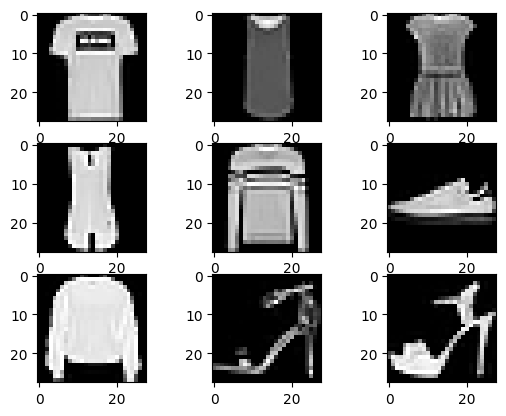

In [52]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [53]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dropout


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7
)

trainX = trainX.reshape((trainX.shape[0], 28, 28, 1)).astype('float32') / 255
testX = testX.reshape((testX.shape[0], 28, 28, 1)).astype('float32') / 255

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2))),
model.add(Dropout(0.25)),
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2))),
model.add(Dropout(0.25)),
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257,162 (1004.54 KB)

 Trainable params: 257,162 (1004.54 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [54]:
history = model.fit(trainX, trainy,
                    epochs=20,
                    batch_size=64,
                    validation_data=(testX, testy),
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7374 - loss: 0.7095 - val_accuracy: 0.8771 - val_loss: 0.3461 - learning_rate: 0.0010
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8807 - loss: 0.3305 - val_accuracy: 0.8945 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8960 - loss: 0.2823 - val_accuracy: 0.9037 - val_loss: 0.2651 - learning_rate: 0.0010
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9067 - loss: 0.2521 - val_accuracy: 0.9018 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9154 - loss: 0.2282 - val_accuracy: 0.9089 - val_loss: 0.2388 - learning_rate: 0.0010
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9196 - loss: 0.2185 - val_accuracy: 0.9106 - val_loss: 0.2425 - learning_rate: 0.0010
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9254 - loss: 0.2014 -

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

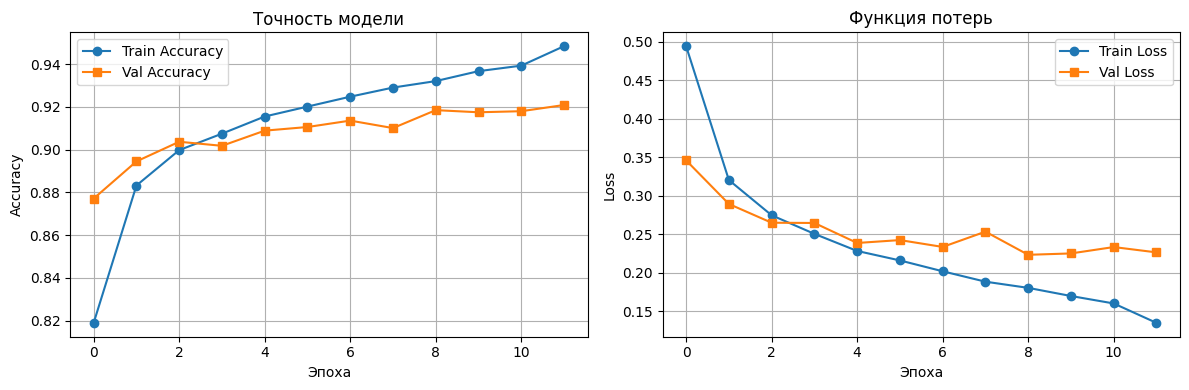

In [55]:
plt.figure(figsize=(12, 4))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



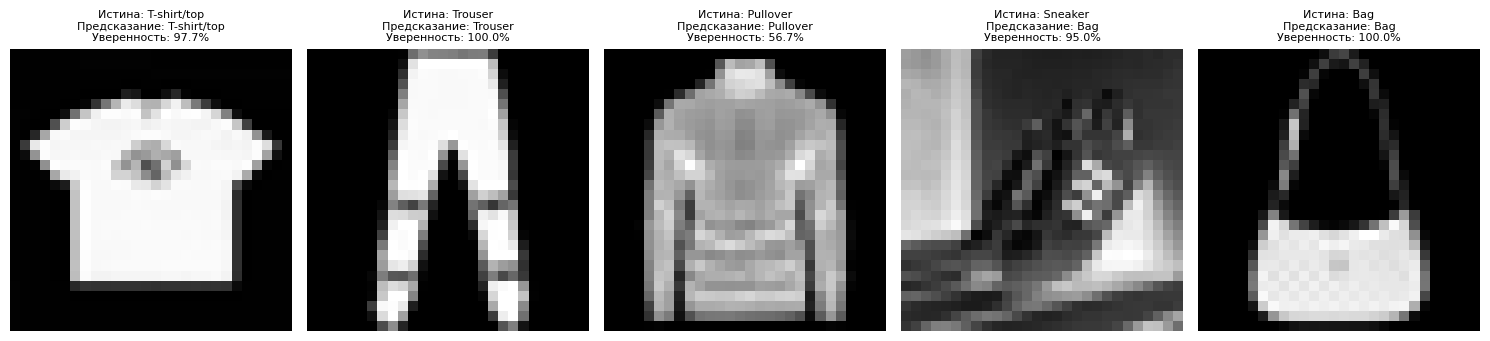

In [59]:
from PIL import Image, ImageOps
import numpy as np

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

images_info = [
    ('/content/futbolka.jpg', 'T-shirt/top'),
    ('/content/shtani.jpg',   'Trouser'),
    ('/content/Pullover.jpg',  'Pullover'),
    ('/content/krossovki.jpg', 'Sneaker'),
    ('/content/Bag.jpg',       'Bag'),
]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, (filename, true_label) in enumerate(images_info):
    img = Image.open(filename).convert('L').resize((28, 28))
    img = ImageOps.invert(img)
    img_arr = np.array(img, dtype='float32') / 255.0
    img_input = img_arr.reshape(1, 28, 28, 1)

    probs = model.predict(img_input, verbose=0)[0]
    pred  = np.argmax(probs)
    conf  = probs[pred] * 100

    axes[i].imshow(img_arr, cmap='gray')
    axes[i].set_title(
        f'Истина: {true_label}\n'
        f'Предсказание: {CLASS_NAMES[pred]}\n'
        f'Уверенность: {conf:.1f}%',
        fontsize=8
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [ ]:
# Ваш код

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Параметры CNN:
Размер: 64x64
Batch: 64, Epochs: 50
LR: 0.0001, L2: 0.001

 Классы: ['cat', 'dog', 'elephant', 'horse', 'lion'] (всего 5)
📂 cat: 2737 изображений
📂 dog: 2627 изображений
📂 elephant: 2730 изображений
📂 horse: 2705 изображений
📂 lion: 2675 изображений

 Классы: ['cat', 'dog', 'elephant', 'horse', 'lion'] (всего 5)
📂 cat: 300 изображений
📂 dog: 300 изображений
📂 elephant: 299 изображений
📂 horse: 300 изображений
📂 lion: 298 изображений

 Train: (13474, 64, 64, 3), Val: (1497, 64, 64, 3)
Метки закодированы:
   y_train: (13474, 5)
   y_val: (1497, 5)
   Классы: ['cat' 'dog' 'elephant' 'horse' 'lion']
Многоклассовая (5 классов): softmax + categorical_crossentropy


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,417,957 (9.22 MB)

...

211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8048 - loss: 0.9027 - val_accuracy: 0.8083 - val_loss: 0.8555 - learning_rate: 1.0000e-04
Epoch 7/50
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8191 - loss: 0.8507
Epoch 7: val_accuracy improved from 0.80828 to 0.81162, saving model to cnn_model.h5


211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8191 - loss: 0.8507 - val_accuracy: 0.8116 - val_loss: 0.8391 - learning_rate: 1.0000e-04
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8316 - loss: 0.8076
Epoch 8: val_accuracy improved from 0.81162 to 0.82231, saving model to cnn_model.h5


211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.8316 - loss: 0.8076 - val_accuracy: 0.8223 - val_loss: 0.8108 - learning_rate: 1.0000e-04
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8464 - loss: 0.7691
Epoch 9: val_accuracy improved from 0.82231 to 0.83100, saving model to cnn_model.h5


211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8464 - loss: 0.7691 - val_accuracy: 0.8310 - val_loss: 0.7989 - learning_rate: 1.0000e-04
Epoch 10/50
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8577 - loss: 0.7331
Epoch 10: val_accuracy did not improve from 0.83100
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8577 - loss: 0.7330 - val_accuracy: 0.8123 - val_loss: 0.8158 - learning_rate: 1.0000e-04
Epoch 11/50
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8686 - loss: 0.7031
Epoch 11: val_accuracy did not improve from 0.83100
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.8686 - loss: 0.7030 - val_accuracy: 0.8090 - val_loss: 0.8417 - learning_rate: 1.0000e-04
Epoch 12/50
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8813 - loss: 0.6704
Epoch 12: val_accuracy did not improve from 0.83100
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8814 - loss: 0.6703 - val_accuracy: 0.8076 - val_loss: 0.8527 - learning_rate: 1.0000e

211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9197 - loss: 0.5713 - val_accuracy: 0.8444 - val_loss: 0.7899 - learning_rate: 5.0000e-05
Epoch 16/50
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9370 - loss: 0.5311
Epoch 16: val_accuracy did not improve from 0.84436
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9370 - loss: 0.5311 - val_accuracy: 0.8397 - val_loss: 0.8205 - learning_rate: 5.0000e-05
Epoch 17/50
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9490 - loss: 0.5028
Epoch 17: val_accuracy did not improve from 0.84436
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9490 - loss: 0.5028 - val_accuracy: 0.8417 - val_loss: 0.8569 - learning_rate: 5.0000e-05
Epoch 18/50
209/211 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9591 - loss: 0.4763
Epoch 18: val_accuracy did not improve from 0.84436
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9591 - loss: 0.4763 - val_accuracy: 0.8323 - val_loss: 0.8990 - learning_rate: 5.0000e

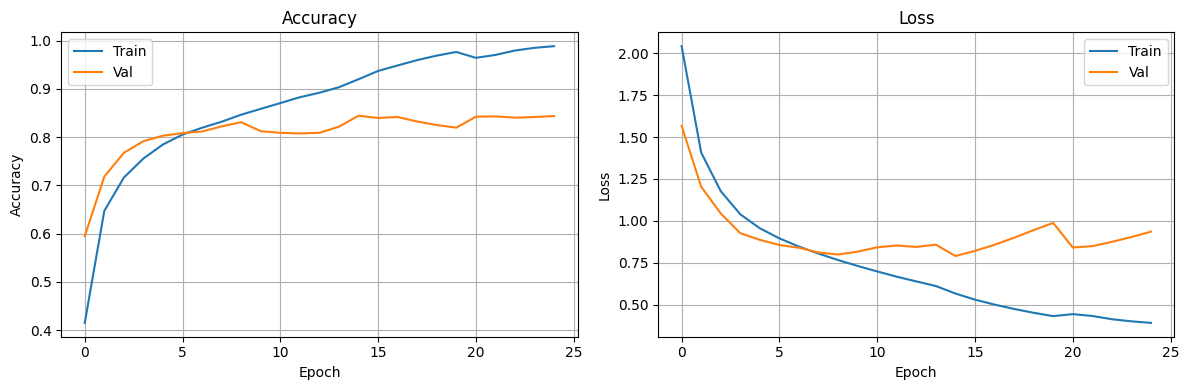

In [62]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.regularizers import l2
from imutils import paths


random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

DATASET_PATH = '/content/drive/MyDrive/animals/train'
VAL_PATH = '/content/drive/MyDrive/animals/val'

IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 0.0001
L2_REG = 0.001

print(f"Параметры CNN:")
print(f"Размер: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch: {BATCH_SIZE}, Epochs: {EPOCHS}")
print(f"LR: {LEARNING_RATE}, L2: {L2_REG}")


def load_dataset_cnn(base_path, img_size=64):
    """Загрузка изображений для CNN"""
    data = []
    labels = []

    classes = sorted([d for d in os.listdir(base_path)
                     if os.path.isdir(os.path.join(base_path, d))])

    print(f"\n Классы: {classes} (всего {len(classes)})")

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]

        print(f"📂 {class_name}: {len(image_files)} изображений")

        for img_file in image_files:
            try:
                img_path = os.path.join(class_path, img_file)
                img = load_img(img_path, target_size=(img_size, img_size))
                img_array = img_to_array(img) / 255.0

                data.append(img_array)
                labels.append(class_name)
            except:
                continue

    return np.array(data, dtype='float32'), np.array(labels), classes

X_train, y_train_str, class_names = load_dataset_cnn(DATASET_PATH, IMG_SIZE)
X_val, y_val_str, _ = load_dataset_cnn(VAL_PATH, IMG_SIZE)

print(f"\n Train: {X_train.shape}, Val: {X_val.shape}")

from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()

y_train = lb.fit_transform(y_train_str)
y_val = lb.transform(y_val_str)

print(f"Метки закодированы:")
print(f"   y_train: {y_train.shape}")
print(f"   y_val: {y_val.shape}")
print(f"   Классы: {lb.classes_}")

if len(lb.classes_) == 2:
    print("Бинарная классификация: используем sigmoid на выходе")
    # Для бинарной: выходной слой Dense(1, activation='sigmoid')
    # loss='binary_crossentropy'
else:
    print(f"Многоклассовая ({len(lb.classes_)} классов): softmax + categorical_crossentropy")

def create_cnn_no_dropout(input_shape, num_classes, l2_reg=0.001):
    model = Sequential([
        # Блок 1: 32 фильтра
        Conv2D(32, (3, 3), padding='same', input_shape=input_shape,
               kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(32, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),

        # Блок 2: 64 фильтра
        Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),

        # Блок 3: 128 фильтров
        Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),

        # Полносвязные слои
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(128, activation='relu', kernel_regularizer=l2(l2_reg)),

        # Выходной слой
        Dense(num_classes, activation='softmax')
    ])

    return model

cnn_model = create_cnn_no_dropout((IMG_SIZE, IMG_SIZE, 3), num_classes, L2_REG)
cnn_model.summary()

optimizer = Adam(learning_rate=LEARNING_RATE)

cnn_model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    ModelCheckpoint(
        'cnn_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks настроены:")
print("   - EarlyStopping (patience=10)")
print("   - ModelCheckpoint (сохранение лучшей)")
print("   - ReduceLROnPlateau (уменьшение LR)")

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

cnn_model.load_weights('cnn_model.h5')

y_pred = cnn_model.predict(X_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_val_classes = np.argmax(y_val, axis=1)

print("\nClassification Report:")
print(classification_report(y_val_classes, y_pred_classes, target_names=class_names))

cnn_accuracy = accuracy_score(y_val_classes, y_pred_classes)
print(f"\nТочность: {cnn_accuracy*100:.2f}%")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [63]:
def create_vgg_like_no_dropout(input_shape, num_classes, l2_reg=0.001):
    model = Sequential([
        # Блок 1: 64 фильтра (2 свёртки)
        Conv2D(64, (3, 3), padding='same', input_shape=input_shape,
               kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Блок 2: 128 фильтров (2 свёртки)
        Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Блок 3: 256 фильтров (3 свёртки)
        Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Блок 4: 512 фильтров (3 свёртки) - если изображение позволяет
        Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(l2_reg)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2), strides=(2, 2)),

        # Полносвязные слои (как в VGG, но с регуляризацией)
        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(256, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dense(128, activation='relu', kernel_regularizer=l2(l2_reg)),

        # Выход
        Dense(num_classes, activation='softmax')
    ])

    return model

vgg_model = create_vgg_like_no_dropout((IMG_SIZE, IMG_SIZE, 3), num_classes, L2_REG)
vgg_model.summary()

print(f"\n Архитектура: VGG-inspired (упрощённая)")
print(f"   - Фильтры: 3×3 (как в оригинале)")
print(f"   - Блоки: 64→128→256→512")
print(f"   - Регуляризация: L2={L2_REG}")

vgg_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('cnn_vgg_no_dropout.h5', monitor='val_accuracy', save_best_only=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

vgg_history = vgg_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=vgg_callbacks,
    verbose=1
)

vgg_model.load_weights('cnn_vgg_no_dropout.h5')

y_pred_vgg = vgg_model.predict(X_val, verbose=0)
y_pred_vgg_classes = np.argmax(y_pred_vgg, axis=1)

print("\n Classification Report (VGG):")
print(classification_report(y_val_classes, y_pred_vgg_classes, target_names=class_names))

vgg_accuracy = accuracy_score(y_val_classes, y_pred_vgg_classes)
print(f"\n Точность VGG: {vgg_accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 8192)           │             

 Total params: 11,994,949 (45.76 MB)

 Trainable params: 11,994,949 (45.76 MB)

...

211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 103ms/step - accuracy: 0.7877 - loss: 1.0800 - val_accuracy: 0.8009 - val_loss: 1.0640 - learning_rate: 1.0000e-04
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8031 - loss: 1.0135
Epoch 8: val_accuracy did not improve from 0.80094
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.8032 - loss: 1.0135 - val_accuracy: 0.7989 - val_loss: 1.0416 - learning_rate: 1.0000e-04
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8105 - loss: 0.9717
Epoch 9: val_accuracy improved from 0.80094 to 0.80628, saving model to cnn_vgg_no_dropout.h5


211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - accuracy: 0.8106 - loss: 0.9716 - val_accuracy: 0.8063 - val_loss: 1.0009 - learning_rate: 1.0000e-04
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8225 - loss: 0.9269
Epoch 10: val_accuracy did not improve from 0.80628
211/211 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - accuracy: 0.8225 - loss: 0.9269 - val_accuracy: 0.8003 - val_loss: 1.0100 - learning_rate: 1.0000e-04
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8302 - loss: 0.8873
Epoch 11: val_accuracy did not improve from 0.80628
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 0.8302 - loss: 0.8873 - val_accuracy: 0.7869 - val_loss: 0.9993 - learning_rate: 1.0000e-04
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8452 - loss: 0.8472
Epoch 12: val_accuracy did not improve from 0.80628
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.8452 - loss: 0.8471 - val_accuracy: 0.7909 - val_loss: 0.9862 - learning_rate:

211/211 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.8626 - loss: 0.7978 - val_accuracy: 0.8250 - val_loss: 0.9108 - learning_rate: 1.0000e-04
Epoch 14/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8759 - loss: 0.7579
Epoch 14: val_accuracy improved from 0.82498 to 0.82766, saving model to cnn_vgg_no_dropout.h5


211/211 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - accuracy: 0.8759 - loss: 0.7579 - val_accuracy: 0.8277 - val_loss: 0.9048 - learning_rate: 1.0000e-04
Epoch 15/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8851 - loss: 0.7280
Epoch 15: val_accuracy did not improve from 0.82766
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.8851 - loss: 0.7280 - val_accuracy: 0.8230 - val_loss: 0.9055 - learning_rate: 1.0000e-04
Epoch 16/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8947 - loss: 0.7087
Epoch 16: val_accuracy did not improve from 0.82766
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.8947 - loss: 0.7088 - val_accuracy: 0.8176 - val_loss: 0.9723 - learning_rate: 1.0000e-04
Epoch 17/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8975 - loss: 0.7030
Epoch 17: val_accuracy did not improve from 0.82766
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.8974 - loss: 0.7030 - val_accuracy: 0.8090 - val_loss: 1.0364 - learning_rate: 1


Epoch 19: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
211/211 ━━━━━━━━━━━━━━━━━━━━ 25s 119ms/step - accuracy: 0.9000 - loss: 0.6859 - val_accuracy: 0.8290 - val_loss: 0.9242 - learning_rate: 1.0000e-04
Epoch 20/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9289 - loss: 0.6118
Epoch 20: val_accuracy did not improve from 0.82899
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.9289 - loss: 0.6118 - val_accuracy: 0.8230 - val_loss: 0.9225 - learning_rate: 5.0000e-05
Epoch 21/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9478 - loss: 0.5664
Epoch 21: val_accuracy did not improve from 0.82899
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9478 - loss: 0.5664 - val_accuracy: 0.8283 - val_loss: 0.9542 - learning_rate: 5.0000e-05
Epoch 22/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9633 - loss: 0.5251
Epoch 22: val_accuracy did not improve from 0.82899
211/211 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.96

## 2.3. Сохраните полученные модели

In [64]:
cnn_model.save('cnn_simple_final.h5')
vgg_model.save('cnn_vgg_final.h5')

print(" Сохранено:")
print("   - cnn_simple_final.h5")
print("   - cnn_vgg_final.h5")

config = {
    'class_names': class_names,
    'img_size': IMG_SIZE,
    'num_classes': num_classes,
    'label_binarizer': lb,
    'l2_reg': L2_REG
}

with open('cnn_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print("   - cnn_config.pkl")

import shutil
for f in ['cnn_simple_final.h5', 'cnn_vgg_final.h5', 'cnn_config.pkl']:
    if os.path.exists(f):
        shutil.copy(f, f'/content/drive/MyDrive/{f}')
        print(f"{f} → Google Drive")

 Сохранено:
   - cnn_simple_final.h5
   - cnn_vgg_final.h5
   - cnn_config.pkl
cnn_simple_final.h5 → Google Drive
cnn_vgg_final.h5 → Google Drive
cnn_config.pkl → Google Drive


## 2.4. Загрузите обученную модель из прошлой практической работы


In [65]:
DENSE_MODEL_PATH = '/content/drive/MyDrive/animals_classifier.h5'
DENSE_CONFIG_PATH = '/content/drive/MyDrive/model_config.pkl'

try:
    with open(DENSE_CONFIG_PATH, 'rb') as f:
        dense_config = pickle.load(f)

    dense_class_names = dense_config['class_names']
    dense_img_size = dense_config['img_size']
    dense_model = load_model(DENSE_MODEL_PATH)

    print(f"Dense модель загружена:")
    print(f"   - Размер: {dense_img_size}x{dense_img_size}")
    print(f"   - Классы: {dense_class_names}")

except FileNotFoundError:
    print("Dense модель не найдена!")
    print("   Создаём заглушку для демонстрации...")

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Flatten

    dense_model = Sequential([
        Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    dense_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    dense_class_names = class_names
    dense_img_size = IMG_SIZE

Dense модель загружена:
   - Размер: 64x64
   - Классы: ['cat', 'dog', 'elephant', 'horse', 'lion']



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

Протестируем 15 изображений...

[1/15] True: lion
   Dense: ✅ lion (82.2%)
   CNN_Simple: ✅ lion (86.9%)
   CNN_VGG: ✅ lion (99.4%)

[2/15] True: cat
   Dense: ✅ cat (92.9%)
   CNN_Simple: ✅ cat (100.0%)
   CNN_VGG: ✅ cat (100.0%)

[3/15] True: lion
   Dense: ❌ cat (88.5%)
   CNN_Simple: ✅ lion (99.8%)
   CNN_VGG: ✅ lion (98.5%)

[4/15] True: horse
   Dense: ✅ horse (49.1%)
   CNN_Simple: ❌ elephant (57.4%)
   CNN_VGG: ✅ horse (99.2%)

[5/15] True: horse
   Dense: ❌ elephant (50.8%)
   CNN_Simple: ✅ horse (96.4%)
   CNN_VGG: ✅ horse (90.7%)

[6/15] True: cat
   Dense: ❌ dog (88.2%)
   CNN_Simple: ✅ cat (100.0%)
   CNN_VGG: ✅ cat (100.0%)

[7/15] True: horse
   Dense: ✅ horse (69.6%)
   CNN_Simple: ✅ horse (99.3%)
   CNN_VGG: ✅ horse (99.0%)

[8/15] True: horse
   Dense: ✅ horse (89.4%)
   CNN_Simple: ✅ horse (91.6%)
   CNN_VGG: ✅ horse (94.2%)

[9/15] True: cat
   Dense: ✅ cat (99.7%)
   CNN_Simple: ✅ cat (100.0%)
   CNN_VGG: ✅ cat (100.0%)

[10/15] True: cat
   Dense: ❌ dog (80.5%)
  

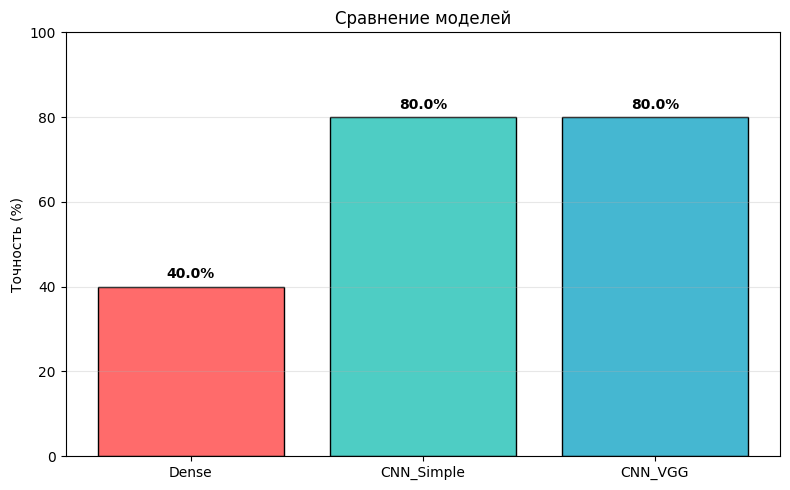


Лучшая: CNN_Simple (80.0%)

ПРИМЕРЫ ПРЕДСКАЗАНИЙ


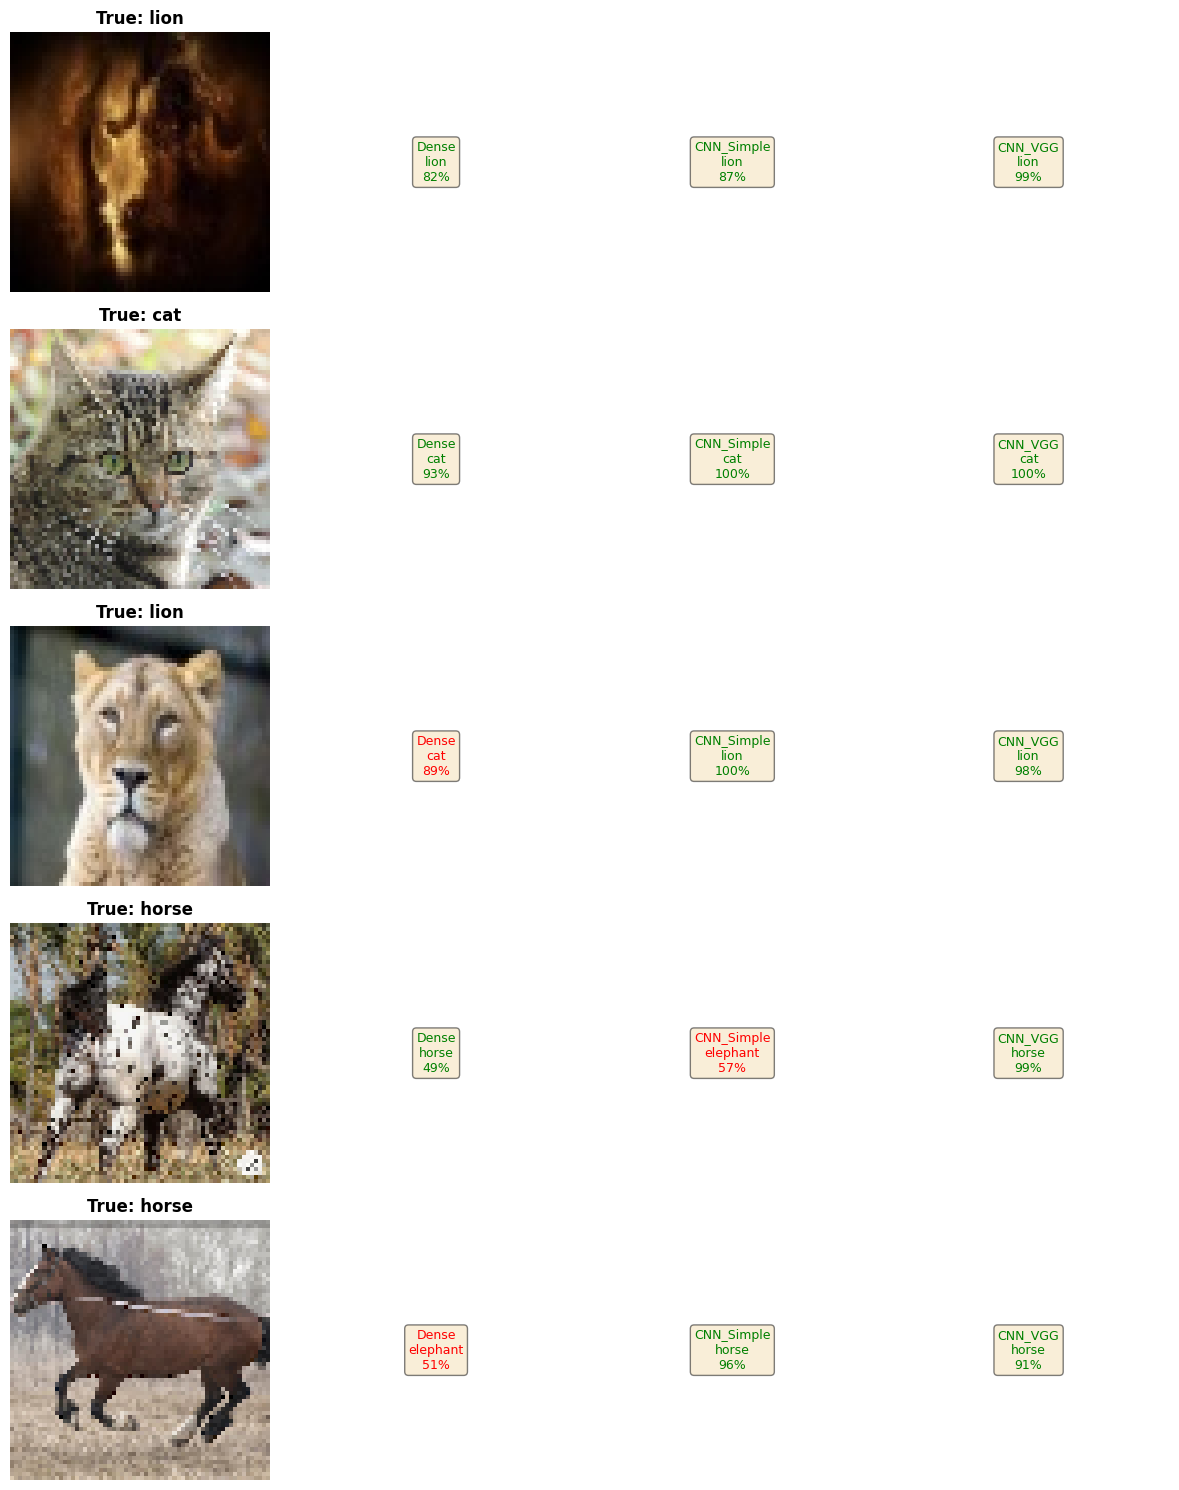

In [66]:
def preprocess_dense(img_array, img_size):
    """Для Dense: flatten"""
    return (img_array / 255.0).flatten().reshape(1, -1)

def preprocess_cnn(img_array, img_size):
    """Для CNN: без flatten"""
    return (img_array / 255.0).reshape(1, img_size, img_size, 3)

def predict_all(img_path, dense_m, cnn_m, vgg_m, classes, img_size):
    """Предсказание всеми моделями"""
    img = load_img(img_path, target_size=(img_size, img_size))
    img_array = img_to_array(img)
    true_class = img_path.split('/')[-2]

    results = {'true': true_class, 'image': img_array}

    if dense_m is not None:
        try:
            x = preprocess_dense(img_array, img_size)
            pred = dense_m.predict(x, verbose=0)[0]
            idx = np.argmax(pred)
            results['Dense'] = {'class': classes[idx], 'conf': float(pred[idx]*100)}
        except:
            results['Dense'] = {'error': 'N/A'}
    else:
        results['Dense'] = {'error': 'Not loaded'}

    x = preprocess_cnn(img_array, img_size)
    pred = cnn_m.predict(x, verbose=0)[0]
    idx = np.argmax(pred)
    results['CNN_Simple'] = {'class': classes[idx], 'conf': float(pred[idx]*100)}

    pred = vgg_m.predict(x, verbose=0)[0]
    idx = np.argmax(pred)
    results['CNN_VGG'] = {'class': classes[idx], 'conf': float(pred[idx]*100)}

    return results

val_paths = []
for cls in class_names:
    cls_path = os.path.join(VAL_PATH, cls)
    if os.path.exists(cls_path):
        val_paths.extend([os.path.join(cls_path, f) for f in os.listdir(cls_path)
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

random.shuffle(val_paths)
test_imgs = val_paths[:15]

print(f"Протестируем {len(test_imgs)} изображений...\n")

# Тестирование
results_list = []
for i, path in enumerate(test_imgs):
    r = predict_all(path, dense_model, cnn_model, vgg_model, class_names, IMG_SIZE)
    results_list.append(r)

    print(f"[{i+1}/15] True: {r['true']}")
    for name in ['Dense', 'CNN_Simple', 'CNN_VGG']:
        if 'error' not in r[name]:
            ok = "✅" if r[name]['class'] == r['true'] else "❌"
            print(f"   {name}: {ok} {r[name]['class']} ({r[name]['conf']:.1f}%)")
        else:
            print(f"   {name}: ❌ {r[name].get('error', 'Error')}")
    print()

# Анализ
print("="*60)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("="*60)

correct = {'Dense': 0, 'CNN_Simple': 0, 'CNN_VGG': 0}
total = {'Dense': 0, 'CNN_Simple': 0, 'CNN_VGG': 0}

for r in results_list:
    for name in ['Dense', 'CNN_Simple', 'CNN_VGG']:
        if 'error' not in r[name]:
            total[name] += 1
            if r[name]['class'] == r['true']:
                correct[name] += 1

print(f"\n{'Модель':<15} {'Правильно':<12} {'Точность':<10}")
print("-" * 40)

accs = {}
for name in ['Dense', 'CNN_Simple', 'CNN_VGG']:
    if total[name] > 0:
        acc = correct[name] / total[name] * 100
        accs[name] = acc
        print(f"{name:<15} {correct[name]}/{total[name]:<8} {acc:.1f}%")

# График
if accs:
    plt.figure(figsize=(8, 5))
    names = list(accs.keys())
    values = [accs[n] for n in names]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    bars = plt.bar(names, values, color=colors, edgecolor='black')
    plt.ylim(0, 100)
    plt.ylabel('Точность (%)')
    plt.title('Сравнение моделей')
    plt.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    best = max(accs, key=accs.get)
    print(f"\nЛучшая: {best} ({accs[best]:.1f}%)")

# Визуализация примеров
print("\n" + "="*60)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("="*60)

fig, axes = plt.subplots(5, 4, figsize=(12, 15))

for i in range(5):
    r = results_list[i]
    img = r['image'] / 255.0
    true = r['true']

    # Изображение
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'True: {true}', fontweight='bold')
    axes[i, 0].axis('off')

    # Предсказания
    for j, name in enumerate(['Dense', 'CNN_Simple', 'CNN_VGG'], 1):
        if 'error' not in r[name]:
            pred = r[name]['class']
            conf = r[name]['conf']
            color = 'green' if pred == true else 'red'
            text = f'{name}\n{pred}\n{conf:.0f}%'
        else:
            text = f'{name}\nN/A'
            color = 'gray'

        axes[i, j].text(0.5, 0.5, text, ha='center', va='center',
                       fontsize=9, color=color,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()


# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [67]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [68]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [69]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

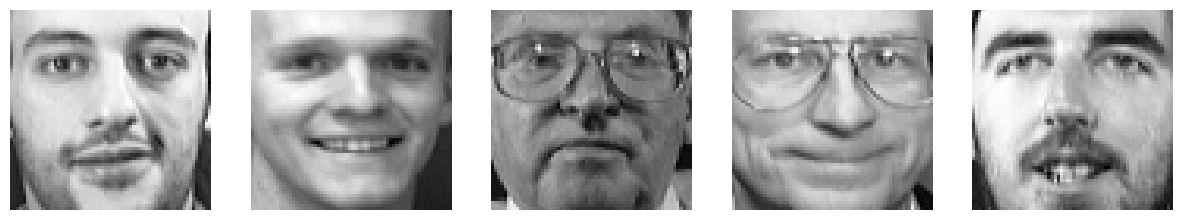

In [70]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [71]:
n_pixels = train.shape[1]

# Upper half of the faces
X_train = train[:, :(n_pixels + 1) // 2, :]
# Lower half of the faces
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [72]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

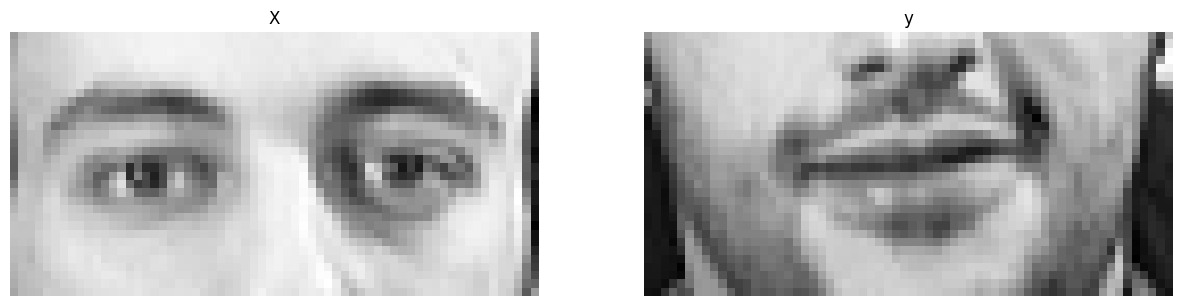

In [73]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [74]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Input

X_train_cnn = X_train.reshape(-1, 32, 64, 1)
X_test_cnn  = X_test.reshape(-1,  32, 64, 1)

model_face = Sequential([
    Input(shape=(32, 64, 1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(2048, activation='sigmoid')
])

model_face.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 32, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 8, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 2048)           │     2,099,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,970,112 (72.37 MB)

 Trainable params: 18,970,112 (72.37 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [83]:
from tensorflow.keras.optimizers import Adam

model_face.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [85]:
def get_callbacks(checkpoint_path, monitor_metric='val_accuracy'):
    early_stopping = EarlyStopping(
        monitor='val_loss', patience=15, min_delta=0.001,
        restore_best_weights=True, verbose=1
    )
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path, monitor=monitor_metric,
        save_best_only=True, verbose=1
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1
    )
    return [early_stopping, checkpoint, reduce_lr]

history_face = model_face.fit(
    X_train_cnn, y_train_n,
    epochs=100, batch_size=32, validation_split=0.15,
    callbacks=get_callbacks('best_face_model.keras', monitor_metric='val_mae'),
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0258 - mae: 0.1310
Epoch 1: val_mae improved from inf to 0.12294, saving model to best_face_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - loss: 0.0256 - mae: 0.1304 - val_loss: 0.0228 - val_mae: 0.1229 - learning_rate: 0.0010
Epoch 2/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0208 - mae: 0.1171 
Epoch 2: val_mae improved from 0.12294 to 0.12139, saving model to best_face_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - loss: 0.0208 - mae: 0.1170 - val_loss: 0.0224 - val_mae: 0.1214 - learning_rate: 0.0010
Epoch 3/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0199 - mae: 0.1143 
Epoch 3: val_mae improved from 0.12139 to 0.12107, saving model to best_face_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - loss: 0.0200 - mae: 0.1144 - val_loss: 0.0222 - val_mae: 0.1211 - learning_rate: 0.0010
Epoch 4/100
7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0198 - mae: 0.1142 
Epoch 4: val_mae improved from 0.12107

## 3.5. Сделайте предсказания на тестовых данных

In [86]:
preds = model_face.predict(X_test_cnn, verbose=0)

## 3.6. Посчитайте метрику качества на тестовых данных

In [87]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(preds, y_test_n)

0.07160621881484985

## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [88]:
pred_test = preds.reshape(-1, 32, 64)

Отрисуйте все предсказания.

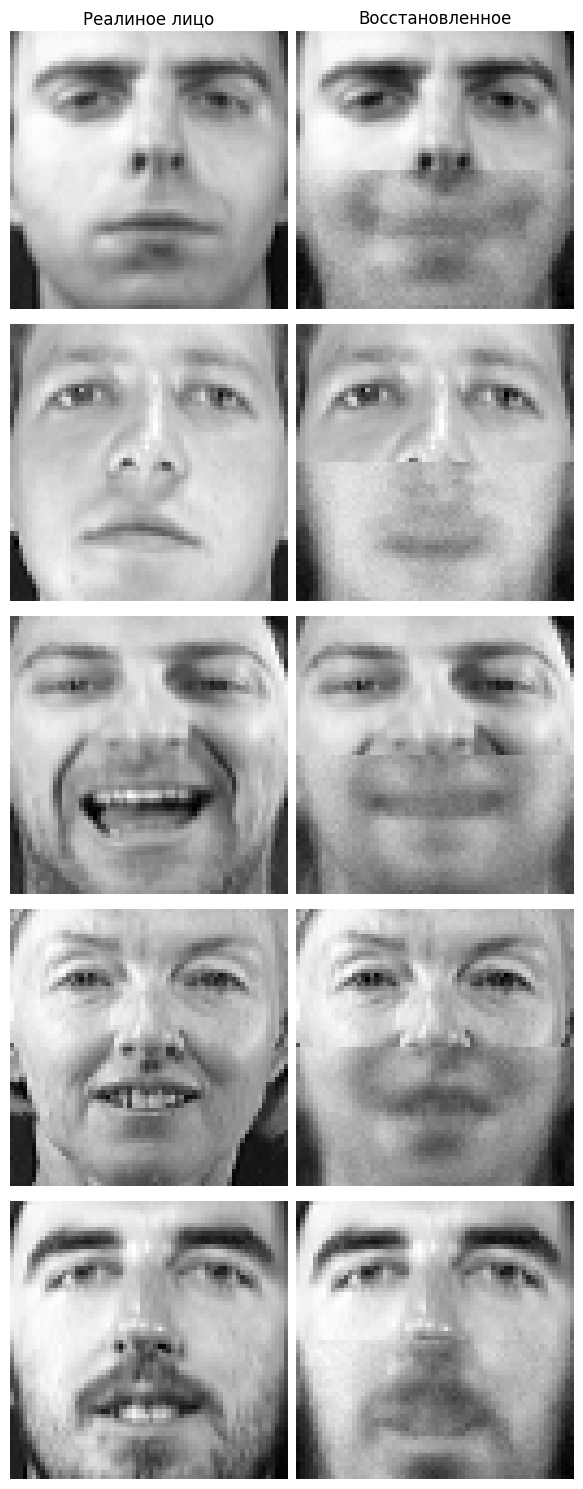

In [89]:
n_faces = 5
image_shape = (64, 64)
plt.figure(figsize=(6, 3 * n_faces))

for i in range(n_faces):
    true_face      = np.vstack((X_test[i], y_test[i]))
    completed_face = np.vstack((X_test[i], pred_test[i]))

    sub = plt.subplot(n_faces, 2, i*2+1)
    if i == 0: sub.set_title('Реалиное лицо')
    sub.imshow(true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation='nearest')
    sub.axis('off')

    sub = plt.subplot(n_faces, 2, i*2+2)
    if i == 0: sub.set_title('Восстановленное')
    sub.imshow(completed_face.reshape(image_shape), cmap=plt.cm.gray, interpolation='nearest')
    sub.axis('off')

plt.tight_layout(); plt.show()

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

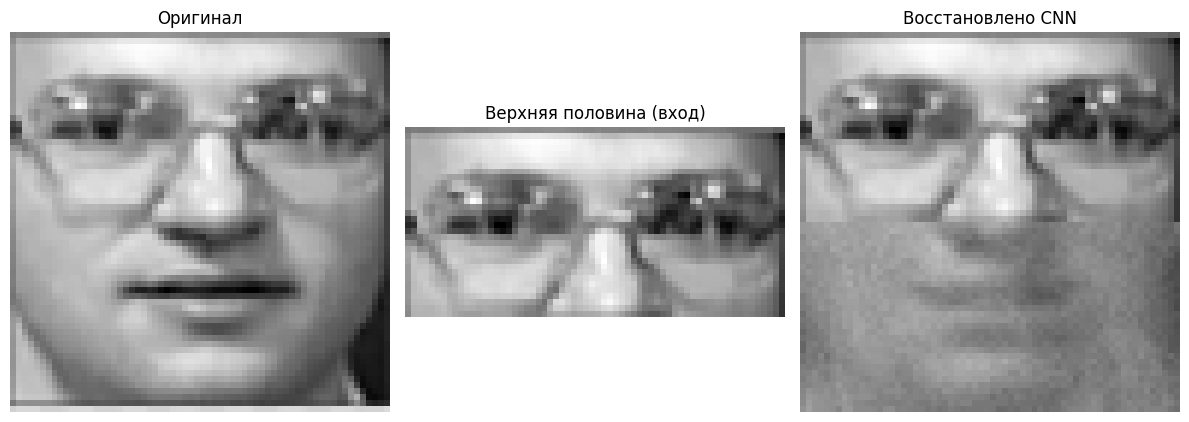

In [100]:
from PIL import Image
import numpy as np

img = Image.open('/content/Снимок.PNG').convert('L').resize((64, 64))
img_arr = np.array(img, dtype='float32') / 255.0
top_half = img_arr[:32, :].reshape(1, 32, 64, 1)

pred_bottom = model_face.predict(top_half, verbose=0).reshape(32, 64)
completed = np.vstack((img_arr[:32, :], pred_bottom))

fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].imshow(img_arr,       cmap='gray'); ax[0].set_title('Оригинал');               ax[0].axis('off')
ax[1].imshow(img_arr[:32,:],cmap='gray'); ax[1].set_title('Верхняя половина (вход)'); ax[1].axis('off')
ax[2].imshow(completed,     cmap='gray'); ax[2].set_title('Восстановлено CNN');        ax[2].axis('off')
plt.tight_layout()
plt.show()